In [1]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [10]:
iris= load_iris()

In [11]:
X= iris.data
y= iris.target

In [13]:
X.shape

(150, 4)

<Axes: >

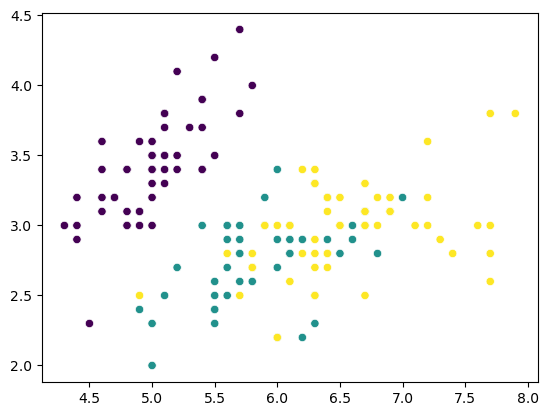

In [25]:
# Visualization
sns.scatterplot (x=X[:,0], y=X[:,1], c=y)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [21]:
# Dimensionality reduction using PCA
from sklearn.decomposition import PCA

pca= PCA(n_components= 2)
pca_data= pca.fit_transform(X_scaled)

In [22]:
# Elbow method
wcss= []

for k in range(1, 11):
    kmeans= KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

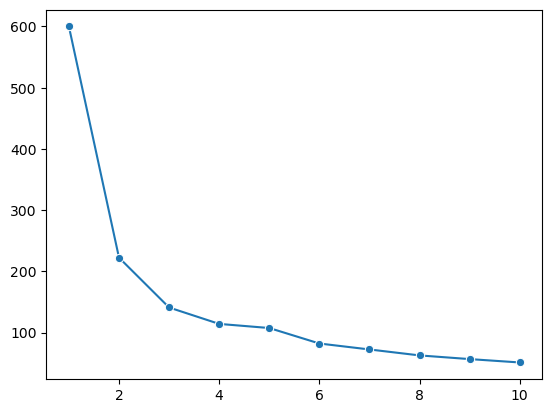

In [19]:
sns.lineplot(x=range(1, 11), y=wcss, marker='o')

C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

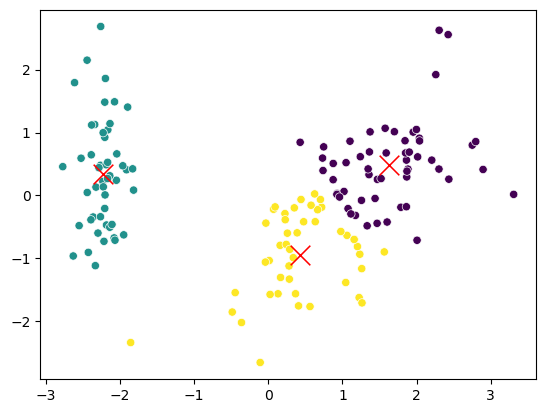

In [29]:
# KMeans
kmeans= KMeans(n_clusters= 3, random_state=10)
labels= kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="x", c="red", s=200)